In [139]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")

In [140]:
pd.set_option("display.max_columns", None)

data = pd.read_pickle("data/cleaned_data.pkl")
processed_data = np.array(data["downsampled_time_series"].tolist())
processed_data = torch.tensor(processed_data, dtype=torch.float32)  # Ensure correct dtype

In [141]:
data.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,NaN,10.206,10.628,10.37,10.46,18.494496,10.206,8.676187,8.861041,0.424,22.037504,22.51405,22.507032,40.056,result\nPOSITIVE_IMPULSE 305.515939\nPOSITI...,2013.020207,124.807,result\nLANDING_RFD 44361.941\nLANDING_RFD ...,1.851,242.302,-0.095,40.056,result\nPEAK_LANDING_FORCE 2750.440318\nPEA...,3826.224,0.389,49.86295,result\nLANDING_IMPULSE 74.115300\nLANDING_...,35920.0,result\nMEAN_ECCENTRIC_FORCE 541.478054\nME...,216.720458,3.928942,57.900625,result\nECCENTRIC_BRAKING_IMPULSE 24.932420...,637.786472,794.063848,result\nECCENTRIC_BRAKING_RFD 3193.798450\n...,result\nECCENTRIC_DECEL_RFD 3196.428571\nEC...,57.948306,result\nPEAK_ECCENTRIC_FORCE 1077.440318\nP...,19.533001,4850.841392,result\nECCENTRIC_DECEL_IMPULSE 42.495925\n...,8.687413,253.440318,result\nECCENTRIC_BRAKING_RFD_100MS 3390.00...,61.457578,-0.775627,479.197727,0.770412,35.659391,36.419146,resul

### Define Autoencoder

In [142]:
# Create Autoencoder 
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        
        self.encoder = nn.Sequential(
            nn.Linear(100, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, self.latent_dim)  
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(self.latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 100),
            # nn.Sigmoid()
        )
    
    def encode(self, x):
        return self.encoder(x)  
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    

### Load Model/Optimizer States

In [ ]:
import torch
import torch.optim as optim

# Define the model and optimizer
latent_dim = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = Autoencoder(latent_dim).to(device)  # Use the Autoencoder class directly
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)

# Load the saved model and optimizer states
model_path = "autoencoder_stochastic.pth"
checkpoint = torch.load(model_path, map_location=device)

autoencoder.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

print(f"Model loaded from {model_path}")

### Add Latent Space Column to Dataframe
This column represents a 16-Dim representation of the encoded time series. 

In [144]:
with torch.no_grad():
    latent_representations = autoencoder.encode(processed_data)

# Convert to list and add to DataFrame
data["latent_space"] = latent_representations.to(device).tolist()

### Look At Consistency In Latent Space
### Group by Person and Session:

We group the data by both the person (profileID) and the session (recordedUTC). This ensures that we compute consistency per individual, and per session.
### Calculate the Mean Latent Space Vector for Each Session:

For each session (which may contain multiple reps or jumps from the same person), calculate the mean latent space vector. This vector represents the "average" jump in the latent space for that person in that session.
### Measure Consistency for Each Jump:

For each individual jump (represented by its latent space vector),  compute how much it deviates from the session’s mean latent vector. This is done by calculating the absolute difference between the jump's latent vector and the mean latent vector across each dimension of the latent space.
### Calculate the Average Deviation:

The consistency is then quantified by calculating the mean of these absolute differences for each jump. This measure shows how much a given jump differs from the session's average, indicating the consistency of the jump relative to others in the same session.

In [145]:
import pandas as pd
import numpy as np

data['latent_space'] = data['latent_space'].apply(np.array)
sessions_and_profiles = data.groupby(['profileID', 'recordedUTC'])
consistency_measures = []

for (profile_id, session_time), session_data in sessions_and_profiles:
    session_latent_means = np.mean(np.stack(session_data['latent_space'].values), axis=0)  
    for latent_vector in session_data['latent_space']:
        diff = np.abs(latent_vector - session_latent_means)   
        mean_diff = np.mean(diff)    
        consistency_measures.append(mean_diff)

data['latent_space_consistency'] = consistency_measures

### How latent_space_consistency is calculated

Taking the latent space mean per session, then for each latent space vector in that session, calculate how far it is from the session mean. This is done by taking the absolute difference in distance between each latent space vector and the session mean. Then, taking the average of all these distances. This consistency measure tells how different each vector (on average) is from the session mean. So if all latent space vectors in a session are very similar, the measure will be small. 

### Indicate Outliers in Dataset

In [146]:
data.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space,latent_space_consistency
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,NaN,10.206,10.628,10.37,10.46,18.494496,10.206,8.676187,8.861041,0.424,22.037504,22.51405,22.507032,40.056,result\nPOSITIVE_IMPULSE 305.515939\nPOSITI...,2013.020207,124.807,result\nLANDING_RFD 44361.941\nLANDING_RFD ...,1.851,242.302,-0.095,40.056,result\nPEAK_LANDING_FORCE 2750.440318\nPEA...,3826.224,0.389,49.86295,result\nLANDING_IMPULSE 74.115300\nLANDING_...,35920.0,result\nMEAN_ECCENTRIC_FORCE 541.478054\nME...,216.720458,3.928942,57.900625,result\nECCENTRIC_BRAKING_IMPULSE 24.932420...,637.786472,794.063848,result\nECCENTRIC_BRAKING_RFD 3193.798450\n...,result\nECCENTRIC_DECEL_RFD 3196.428571\nEC...,57.948306,result\nPEAK_ECCENTRIC_FORCE 1077.440318\nP...,19.533001,4850.841392,result\nECCENTRIC_DECEL_IMPULSE 42.495925\n...,8.687413,253.440318,result\nECCENTRIC_BRAKING_RFD_100MS 3390.00...,61.457578,-0.775627,479.197

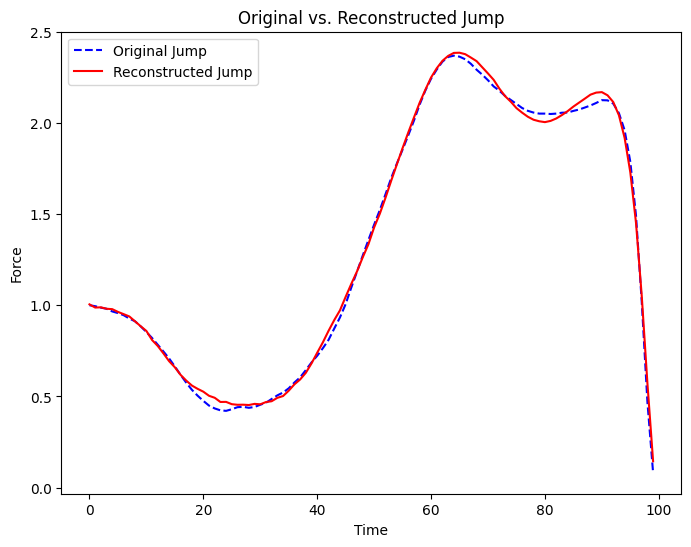

In [203]:
import matplotlib.pyplot as plt
import torch

def plot_reconstruction(autoencoder, data, index=1, save_path="reconstructed_jump.png"):
    """
    Plots the original and reconstructed jump for a given index in the dataset.
    Saves the plot as an image.
    """
    original = torch.tensor(data.iloc[index]["downsampled_time_series"], dtype=torch.float32)
    latent = torch.tensor(data.iloc[index]["latent_space"], dtype=torch.float32)

    with torch.no_grad():
        reconstructed = autoencoder.decoder(latent).numpy()

    plt.figure(figsize=(8, 6))
    plt.plot(original, label="Original Jump", linestyle="dashed", color="blue")
    plt.plot(reconstructed, label="Reconstructed Jump", color="red")
    plt.xlabel("Time")
    plt.ylabel("Force")
    plt.title("Original vs. Reconstructed Jump")
    plt.legend()

    # Save the figure as a PNG file
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# Example usage (plot the 100th jump and save the image)
plot_reconstruction(autoencoder, data, index=100, save_path="reconstructed_jump_100.png")


Original downsampled time series (index 100):
[1.0005506  0.99543756 0.987414   0.9814094  0.966647   0.9575484
 0.94603735 0.92776144 0.9125271  0.88447076 0.8536612  0.820754
 0.78367764 0.74657506 0.7079779  0.66455615 0.6186958  0.5754838
 0.5363097  0.50411046 0.4757132  0.4499119  0.4342842  0.42382205
 0.42106885 0.4299053  0.44115406 0.44306824 0.43771914 0.44236022
 0.45447427 0.46540835 0.48620155 0.5059459  0.52162594 0.5447003
 0.57661116 0.60472    0.64465433 0.6865553  0.7232384  0.76492965
 0.8108161  0.8729072  0.9337135  1.0070271  1.0986166  1.1855127
 1.2731954  1.3590689  1.4429493  1.5232378  1.6098979  1.6987343
 1.7785769  1.8549058  1.9335948  2.014224   2.1020901  2.1790223
 2.2439191  2.2940798  2.3372655  2.363041   2.370278   2.3647976
 2.350586   2.3254664  2.29311    2.2658398  2.2354236  2.2014678
 2.1778426  2.149393   2.1273675  2.105342   2.0829754  2.0675838
 2.0580132  2.052323   2.0522707  2.0501468  2.0523756  2.0572789
 2.0581443  2.0671904  2.074

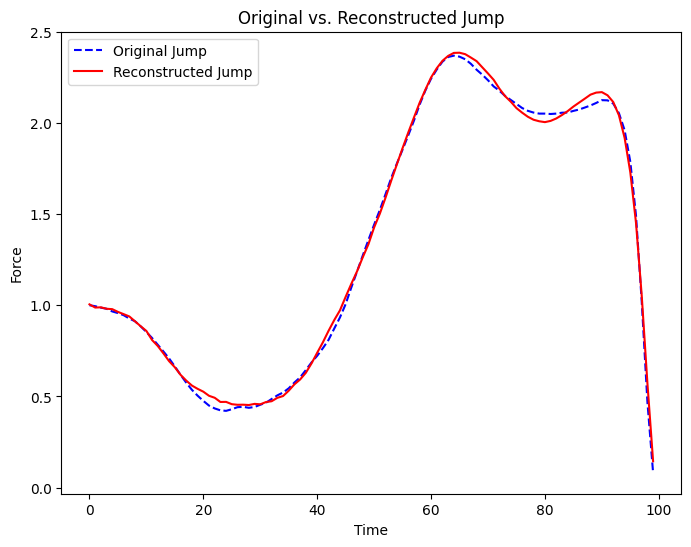

In [205]:
import matplotlib.pyplot as plt
import torch

def plot_reconstruction(autoencoder, data, index=1, save_path="reconstructed_jump.png"):
    """
    Plots the original and reconstructed jump for a given index in the dataset.
    Saves the plot as an image.
    Also prints the downsampled time series, the latent space, and the reconstructed time series.
    """
    original = torch.tensor(data.iloc[index]["downsampled_time_series"], dtype=torch.float32)
    latent = torch.tensor(data.iloc[index]["latent_space"], dtype=torch.float32)

    # Print downsampled time series and latent space
    print(f"Original downsampled time series (index {index}):")
    print(original.numpy())
    print("\nCorresponding latent space representation:")
    print(latent.numpy())

    # Reconstruct the time series from the latent space
    with torch.no_grad():
        reconstructed = autoencoder.decoder(latent).numpy()

    print("\nReconstructed jump (from latent space):")
    print(reconstructed)

    plt.figure(figsize=(8, 6))
    plt.plot(original, label="Original Jump", linestyle="dashed", color="blue")
    plt.plot(reconstructed, label="Reconstructed Jump", color="red")
    plt.xlabel("Time")
    plt.ylabel("Force")
    plt.title("Original vs. Reconstructed Jump")
    plt.legend()

    # Save the figure as a PNG file
    # plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# Example usage (plot the 100th jump and save the image)
plot_reconstruction(autoencoder, data, index=100, save_path="reconstructed_jump_100.png")


Original downsampled time series (index 100):
[1.0005506  0.99543756 0.987414   0.9814094  0.966647   0.9575484
 0.94603735 0.92776144 0.9125271  0.88447076 0.8536612  0.820754
 0.78367764 0.74657506 0.7079779  0.66455615 0.6186958  0.5754838
 0.5363097  0.50411046 0.4757132  0.4499119  0.4342842  0.42382205
 0.42106885 0.4299053  0.44115406 0.44306824 0.43771914 0.44236022
 0.45447427 0.46540835 0.48620155 0.5059459  0.52162594 0.5447003
 0.57661116 0.60472    0.64465433 0.6865553  0.7232384  0.76492965
 0.8108161  0.8729072  0.9337135  1.0070271  1.0986166  1.1855127
 1.2731954  1.3590689  1.4429493  1.5232378  1.6098979  1.6987343
 1.7785769  1.8549058  1.9335948  2.014224   2.1020901  2.1790223
 2.2439191  2.2940798  2.3372655  2.363041   2.370278   2.3647976
 2.350586   2.3254664  2.29311    2.2658398  2.2354236  2.2014678
 2.1778426  2.149393   2.1273675  2.105342   2.0829754  2.0675838
 2.0580132  2.052323   2.0522707  2.0501468  2.0523756  2.0572789
 2.0581443  2.0671904  2.074

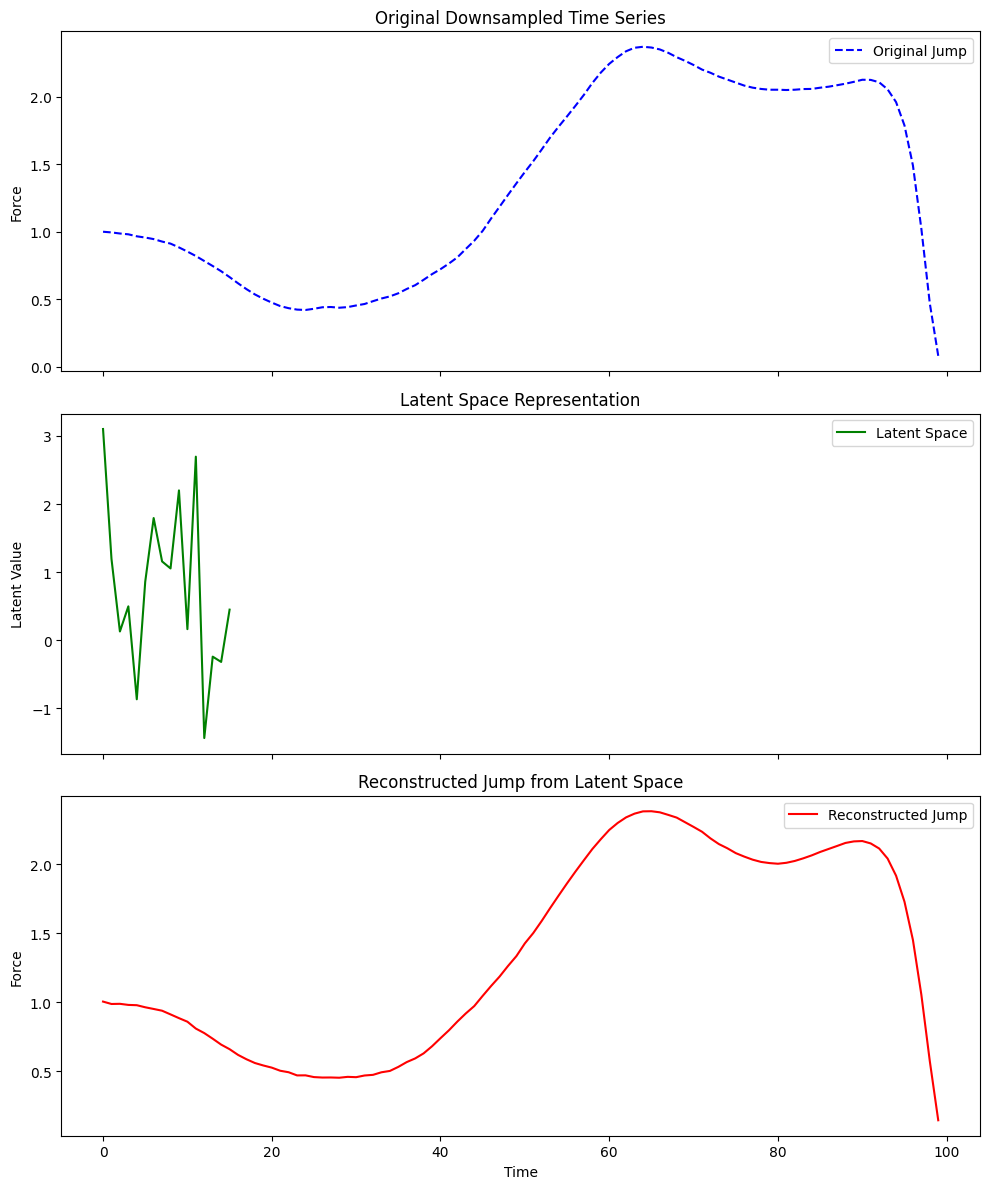

In [155]:
import torch.nn.functional as F
import numpy as np

def compute_reconstruction(autoencoder, data):
    losses = []
    reconstructions = []
    
    for _, row in data.iterrows():
        original = torch.tensor(row["downsampled_time_series"], dtype=torch.float32)
        latent = torch.tensor(row["latent_space"], dtype=torch.float32)
        
        with torch.no_grad():
            reconstructed = autoencoder.decoder(latent)
        
        loss = F.mse_loss(reconstructed, original)
        losses.append(loss.item())
        reconstructions.append(reconstructed.numpy())  # Convert tensor to numpy array
    
    return np.array(losses), reconstructions


reconstruction_losses, reconstructions = compute_reconstruction(autoencoder, data)

data["reconstruction_loss"] = reconstruction_losses
data["reconstruction"] = reconstructions

reconstruction_threshold = np.percentile(data["reconstruction_loss"], 99)
avg_threshold = np.percentile(data["downsampled_time_series"].apply(np.mean), 95)

# Outliers defined by: reconstruction error being above the 99th percentile, the average of the downsampled 
# time series being above the 95th percentile, and the initial value of a downsampled time series being above 0.7
data["outlier"] = (
    (data["latent_space_consistency"] > 5) | 
    (data["JUMP_HEIGHT_INCHES"] > 40) |  
    (data["reconstruction_loss"] > reconstruction_threshold) | 
    (data["downsampled_time_series"].apply(np.mean) > avg_threshold) 
).astype(int)

data.head(1)


,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space,latent_space_consistency,reconstruction_loss,reconstruction,total_sessions,start_year,years_training,outlier
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,NaN,10.206,10.628,10.37,10.46,18.494496,10.206,8.676187,8.861041,0.424,22.037504,22.51405,22.507032,40.056,result\nPOSITIVE_IMPULSE 305.515939\nPOSITI...,2013.020207,124.807,result\nLANDING_RFD 44361.941\nLANDING_RFD ...,1.851,242.302,-0.095,40.056,result\nPEAK_LANDING_FORCE 2750.440318\nPEA...,3826.224,0.389,49.86295,result\nLANDING_IMPULSE 74.115300\nLANDING_...,35920.0,result\nMEAN_ECCENTRIC_FORCE 541.478054\nME...,216.720458,3.928942,57.900625,result\nECCENTRIC_BRAKING_IMPULSE 24.932420...,637.786472,794.063848,result\nECCENTRIC_BRAKING_RFD 3193.798450\n...,result\nECCENTRIC_DECEL_RFD 3196.428571\nEC...,57.948306,result\nPEAK_ECCENTRIC_FORCE 1077.440318\nP...,19.533001,4850.841392,result\nECCENTRIC_DECEL_IMPULSE 42.495925\n...,8.687413,2

### BoxPlot of Yearly Latent Space Consistency
### Preprocessing Data:

The recordedUTC column is converted to datetime format.
A new column start_year is created, representing the year when each athlete (identified by profileID) started training.
The years_training column is then computed by subtracting the start_year from the current year of each record in recordedUTC.
### Computing Latent Space Differences:

The code calculates the difference between each training rep’s latent vector and the mean latent vector of the same year. This difference is measured using the Euclidean norm (torch.norm).
For each athlete and each year of training, the difference for each rep is stored along with the profileID, years_training, and a flag for whether the rep is an outlier (based on a previous classification).
### Handling Outliers:

The outlier column tracks whether each rep is considered an outlier, which was previously determined by reconstruction loss.
The data is filtered to exclude outliers, and the non-outlier data is stored in filtered_diff_df.

In [156]:
# Add column for total sessions for a profileID
data['total_sessions'] = data.groupby('profileID')['testID'].transform('nunique')

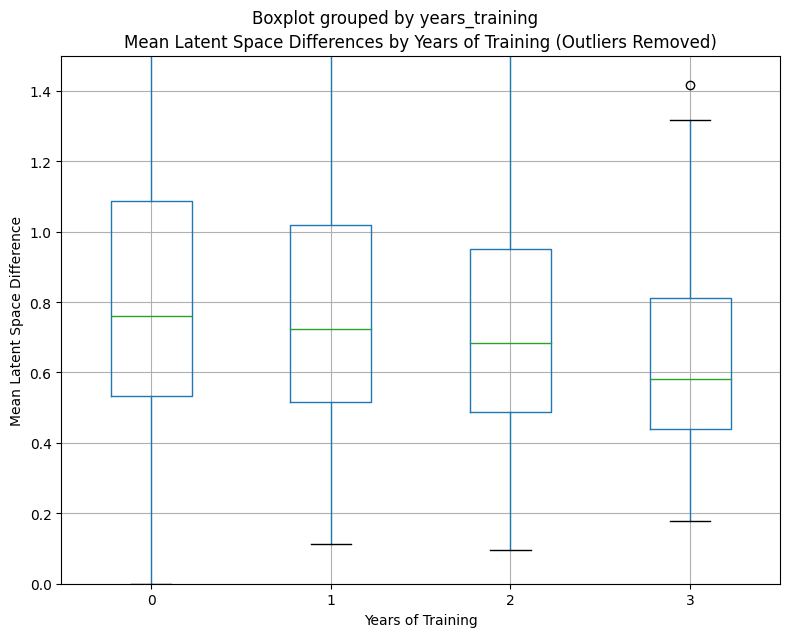

In [188]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

data['recordedUTC'] = pd.to_datetime(data['recordedUTC'])

data['start_year'] = data.groupby('profileID')['recordedUTC'].transform('min').dt.year
data['years_training'] = data['recordedUTC'].dt.year - data['start_year']

data['latent_space'] = data['latent_space'].apply(np.array)

differences_per_year = []

for profile_id, profile_data in data.groupby('profileID'):
    for year, year_data in profile_data.groupby('years_training'):
        
        latent_vectors = torch.tensor(np.stack(year_data['latent_space'].values), dtype=torch.float32)
        
        # mean latent space vector for this year
        mean_latent = latent_vectors.mean(dim=0)
        
        # mean difference between each rep and the yearly mean
        differences = torch.norm(latent_vectors - mean_latent, dim=1).numpy() # Euclidean distance
        
        for diff, (_, row) in zip(differences, year_data.iterrows()):
            differences_per_year.append({
                'profileID': profile_id, 
                'years_training': year, 
                'difference': diff, 
                'outlier': row['outlier']  
            })

diff_df = pd.DataFrame(differences_per_year)

filtered_diff_df = diff_df[diff_df["outlier"] == 0]

plt.figure(figsize=(8, 12))  
ax1 = plt.subplot(211)  
filtered_diff_df.boxplot(column='difference', by='years_training', ax=ax1)
ax1.set_ylim(0, 1.5)  
ax1.set_title("Mean Latent Space Differences by Years of Training (Outliers Removed)")
ax1.set_xlabel("Years of Training")
ax1.set_ylabel("Mean Latent Space Difference")
ax1.grid(True)

plt.tight_layout()

# Save the plot as an image
plt.savefig("latent_space_consistency.png", dpi=300, bbox_inches="tight")

plt.show()


In [191]:
# Calculate the average difference for each year of training
avg_diff_per_year = filtered_diff_df.groupby('years_training')['difference'].median()

# Display the average differences
print(avg_diff_per_year)


years_training
0    0.760561
1    0.724872
2    0.684363
3    0.582895
Name: difference, dtype: float32


In [193]:
x1 = 0.760561
x2 = 0.724872
x3 = 0.684363
x4 = 0.582895

values = [x1, x2, x3, x4]

# Compute pairwise differences
differences = [abs(values[i] - values[i+1]) for i in range(len(values) - 1)]

# Compute the average difference
average_difference = sum(differences) / len(differences)

print("Average Difference:", average_difference)

Average Difference: 0.059222


### Using Mixed Linear Model to Determine Significance

Random effects allow for individual variations. By specifying groups=filtered_diff_df["profileID"], each unique profileID (e.g., each athlete) can have its own intercept that differs from others. This helps account for variability per athlete. 

In [159]:
import statsmodels.formula.api as smf

model = smf.mixedlm("difference ~ years_training", filtered_diff_df, groups=filtered_diff_df["profileID"])
res = model.fit()

print(res.summary())


          Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: difference 
No. Observations:  28277   Method:             REML       
No. Groups:        705     Scale:              0.1856     
Min. group size:   1       Log-Likelihood:     -17049.9477
Max. group size:   135     Converged:          Yes        
Mean group size:   40.1                                   
----------------------------------------------------------
               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept       0.854    0.009  89.976 0.000  0.836  0.873
years_training -0.061    0.005 -13.050 0.000 -0.070 -0.051
Group Var       0.047    0.008                            



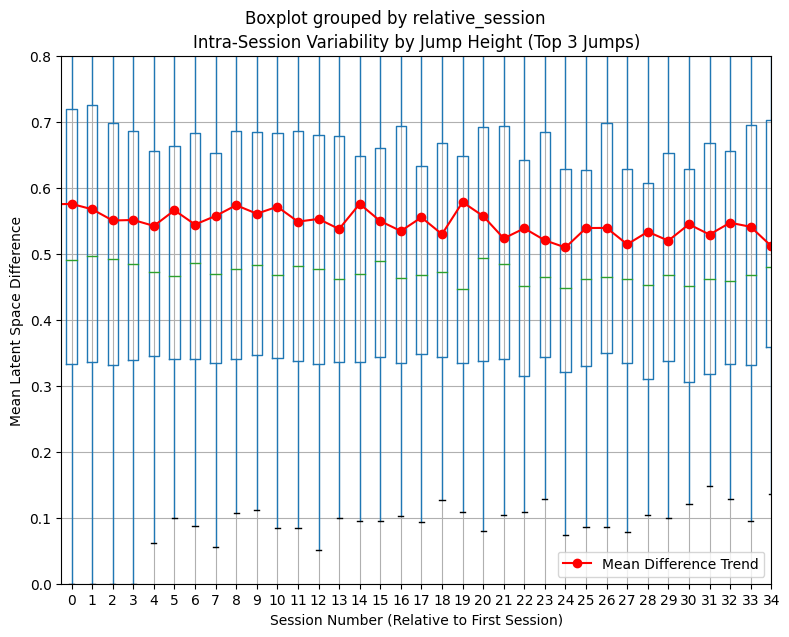

In [160]:
differences_per_session = []

data['first_session_date'] = data.groupby('profileID')['recordedUTC'].transform('min')

data['relative_session'] = data.groupby('profileID')['recordedUTC'].rank(method='dense').astype(int) - 1

for profile_id, profile_data in data.groupby('profileID'):
    for session_idx, session_data in profile_data.groupby('relative_session'):
        
        if len(session_data) >= 3:  
            
            top_3_height = session_data.nlargest(3, 'JUMP_HEIGHT_INCHES')
            latent_vectors_height = torch.tensor(np.stack(top_3_height['latent_space'].values), dtype=torch.float32)
            
            mean_latent_height = latent_vectors_height.mean(dim=0)
            
            differences_height = torch.norm(latent_vectors_height - mean_latent_height, dim=1).numpy()
            
            for diff, (_, row) in zip(differences_height, top_3_height.iterrows()):
                differences_per_session.append({
                    'profileID': profile_id, 
                    'relative_session': session_idx,  
                    'difference': diff, 
                    'outlier': row['outlier'],  
                    'selection_criteria': 'jump_height'
                })

session_diff_df = pd.DataFrame(differences_per_session)

filtered_session_diff_df = session_diff_df[session_diff_df["outlier"] == 0]

plt.figure(figsize=(8, 12))
ax1 = plt.subplot(211)

# Boxplot
filtered_session_diff_df[filtered_session_diff_df["selection_criteria"] == "jump_height"].boxplot(column='difference', by='relative_session', ax=ax1)
ax1.set_ylim(0, 0.8)
ax1.set_xlim(0.5, 35)
ax1.set_title("Intra-Session Variability by Jump Height (Top 3 Jumps)")
ax1.set_xlabel("Session Number (Relative to First Session)")
ax1.set_ylabel("Mean Latent Space Difference")
ax1.grid(True)

trend_data = filtered_session_diff_df[filtered_session_diff_df["selection_criteria"] == "jump_height"].groupby("relative_session")["difference"].mean()

ax1.plot(trend_data.index, trend_data.values, marker="o", linestyle="-", color="red", label="Mean Difference Trend")

ax1.legend()

plt.tight_layout()
plt.show()

# difference between each training rep’s latent vector and the mean latent vector of the top 3 jumps by height of that session

### Final Summary

For each additional year of training, latent space variation decreases by 0.083 on average.

Athletes with more years of training tend to have reduced variability in latent space differences.

There is significant individual variability in baseline difference.

### Outlier DataFrame

In [161]:
reconstruction_threshold = 0.010
# data["outlier"] = (
#     (data["latent_space_consistency"] > 5) | 
#     (data["JUMP_HEIGHT_INCHES"] > 40) |  
#     (data["reconstruction_loss"] > reconstruction_threshold) | 
#     (data["downsampled_time_series"].apply(np.mean) > avg_threshold) 
    # (data["downsampled_time_series"].apply(lambda x: x[0] if isinstance(x, list) else 0) > 0.7) | 
    # (data["downsampled_time_series"].apply(lambda y: y[-1] if isinstance(y, list) else 0) > 0.3)
# ).astype(int)

# data["outlier"] = (
#     ([data["latent_space_consistency"] > 5) | 
#     ([data["JUMP_HEIGHT_INCHES"] > 40)
# ).astype(int)
      
outliers_df = data[data["outlier"] == 1]
non_outliers_df = data[data["outlier"] == 0]
x = len(outliers_df)
y = len(data[data["outlier"] == 0])
print(f"{x} outliers detected, {y} non-outliers.")

1735 outliers detected, 28277 non-outliers.


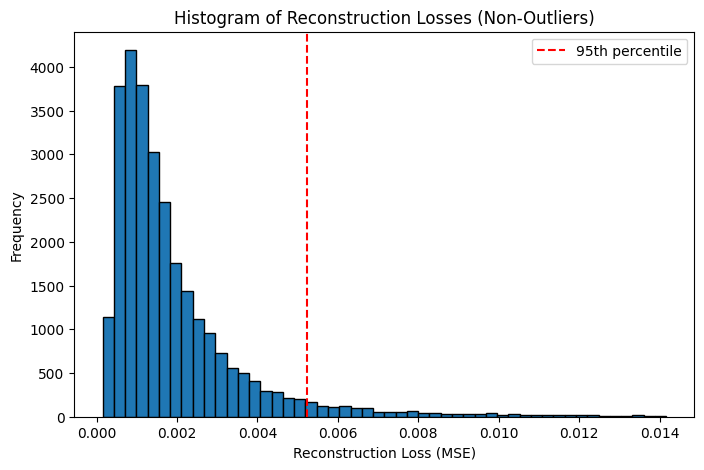

In [162]:
plt.figure(figsize=(8,5))
plt.hist(non_outliers_df["reconstruction_loss"], bins=50, edgecolor='black')
plt.xlabel("Reconstruction Loss (MSE)")
plt.ylabel("Frequency")
plt.title("Histogram of Reconstruction Losses (Non-Outliers)")
plt.axvline(np.percentile(non_outliers_df["reconstruction_loss"], 95), color='red', linestyle='dashed', label="95th percentile")
plt.legend()
plt.show()


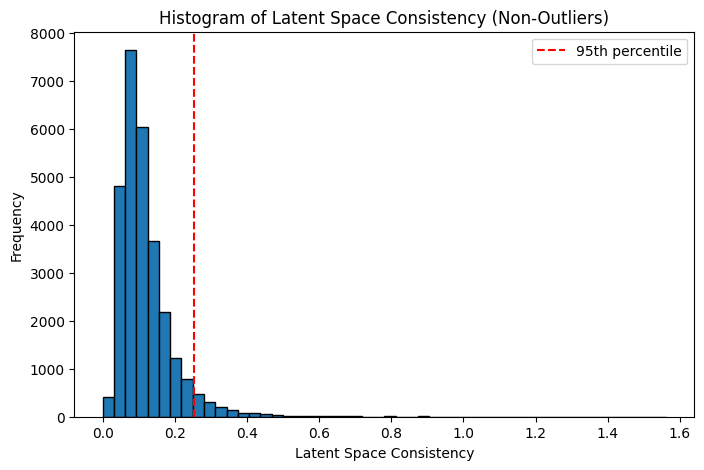

In [163]:
plt.figure(figsize=(8,5))
plt.hist(non_outliers_df["latent_space_consistency"], bins=50, edgecolor='black')
plt.xlabel("Latent Space Consistency")
plt.ylabel("Frequency")
plt.title("Histogram of Latent Space Consistency (Non-Outliers)")
plt.axvline(np.percentile(non_outliers_df["latent_space_consistency"], 95), color='red', linestyle='dashed', label="95th percentile")
plt.legend()
plt.show()


In [164]:
len_profile_outliers = len(outliers_df["profileID"].unique())
print(f"{len_profile_outliers} profiles with outliers detected.")

245 profiles with outliers detected.


In [165]:
more_than_2_years = data[data["years_training"] > 2]
more_than_2_years_unique = more_than_2_years["profileID"].unique()
total_people = len(data["profileID"].unique())
print(f"{len(more_than_2_years_unique)} people out of {total_people} have 3 years of training data")


25 people out of 707 have 3 years of training data


In [166]:
outliers_df[['testID', 'rep']].to_csv('outliers.csv', index=False)

print("CSV Saved Succesfully")

CSV Saved Succesfully


### Test Whether Years Training is a Statistically Significant Predictor of Latent Space Consistency

Using Ordinary Least Squares Regression



In [167]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Ensure latent space is stored as NumPy arrays
non_outliers_df["latent_space"] = non_outliers_df["latent_space"].apply(np.array)


/tmp/ipykernel_3094/1092024400.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outliers_df["latent_space"] = non_outliers_df["latent_space"].apply(np.array)


### t-SNE Color Coded by Jump Height

This code performs t-SNE (t-Distributed Stochastic Neighbor Embedding) on a combination of latent space features and jump-related metrics from a subset of the data. First, it selects a sample of 1000 entries from the non_outliers_df dataset and standardizes the jump features (JUMP_HEIGHT_INCHES and JUMP_HEIGHT_INCHES_IMP_MOM) to have zero mean and unit variance. The latent space vectors are then stacked into a matrix, and these matrices are combined with the standardized jump features into a single feature matrix. The t-SNE algorithm is applied to reduce the dimensionality of this combined data to two components, which are stored in the dataset. Finally, a scatter plot of the t-SNE results is generated, where the points are color-coded by JUMP_HEIGHT_INCHES, providing a visual representation of the relationships between the latent space and jump height features in a lower-dimensional space.

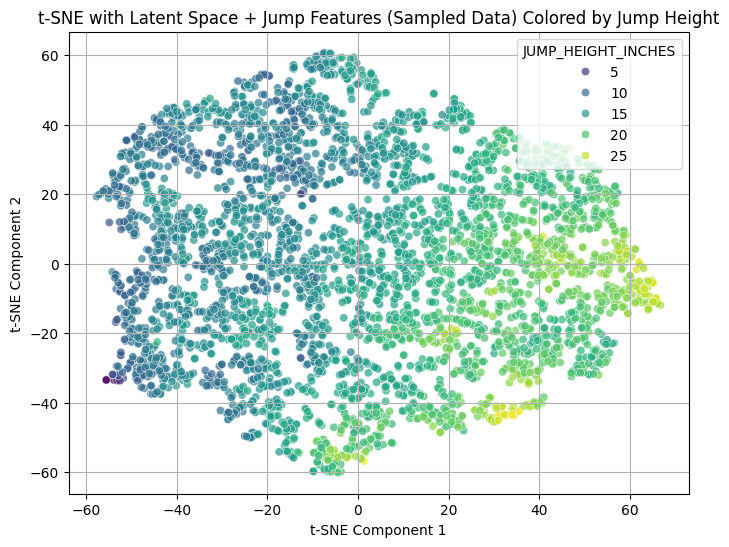

In [168]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

jump_features = ["JUMP_HEIGHT_INCHES"]

sampled_df = non_outliers_df.sample(n=4000, random_state=42)

scaler = StandardScaler()
feature_matrix = scaler.fit_transform(sampled_df[jump_features])

# Stack latent space into a matrix
latent_matrix = np.stack(sampled_df["latent_space"].values)

# Concatenate latent space with the jump features
combined_matrix = np.hstack((latent_matrix, feature_matrix))

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
combined_tsne = tsne.fit_transform(combined_matrix)

sampled_df["tsne_combined_1"] = combined_tsne[:, 0]
sampled_df["tsne_combined_2"] = combined_tsne[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(x="tsne_combined_1", y="tsne_combined_2", 
                data=sampled_df, alpha=0.7, hue="JUMP_HEIGHT_INCHES", palette="viridis")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE with Latent Space + Jump Features (Sampled Data) Colored by Jump Height")
plt.grid(True)
plt.show()


In [169]:
# data[data["years_training"] == 3]["start_year"].unique()

# total force / 9.8
# take difference btween low and high and divide by that
# divide by first value in total_force for each row -> set max to peak force

### t-SNE Color by Body Weight

In [170]:
sampled_df["initial_weight"] = sampled_df["total_force"].apply(lambda x: x[0] if isinstance(x, list) or isinstance(x, np.ndarray) else np.nan)

In [171]:
sampled_df.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space,latent_space_consistency,reconstruction_loss,reconstruction,total_sessions,start_year,years_training,outlier,first_session_date,relative_session,tsne_combined_1,tsne_combined_2,initial_weight
1231,1168,1168,2a0cbdd3-da12-4f04-9369-d20f04824a2f,1,6625e053-7df7-4fda-b7f4-ce493f1bc2e6,2024-09-27 19:22:00.564000+00:00,Acro and Tumbling,Team,NaN,47.55,47.55,18.504,18.986,18.662,18.82,14.63111,18.504,9.343349,8.839707,0.44,23.732093,22.615645,22.452843,39.692,result\nPOSITIVE_IMPULSE 281.960383\nPOSITI...,1771.015833,99.177,result\nLANDING_RFD 42029.912\nLANDING_RFD ...,2.193,224.288,-0.095,39.692,result\nPEAK_LANDING_FORCE 2353.675097\nPEA...,3808.966,0.269,49.498951,result\nLANDING_IMPULSE 59.611805\nLANDING_...,44400.0,result\nMEAN_ECCENTRIC_FORCE 468.158568\nME...,291.500127,6.130392,60.624943,result\nECCENTRIC_BRAKING_IMPULSE 23.293520...,538.527858,818.734621,result\nECCENTRIC_BRAKING_RFD 2882.716049\n...,result\nECCENTRIC_DECEL_RFD 3590.361446\nEC...,75.507076,result\nPEAK_ECCENTRIC_FORCE 10

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Function to get the reconstructed jump from the latent vector using the autoencoder
def get_reconstructed_jump(latent_vector):
    latent_tensor = torch.tensor(latent_vector, dtype=torch.float32)
    reconstructed_jump = autoencoder.decoder(latent_tensor)
    return reconstructed_jump.detach().numpy()


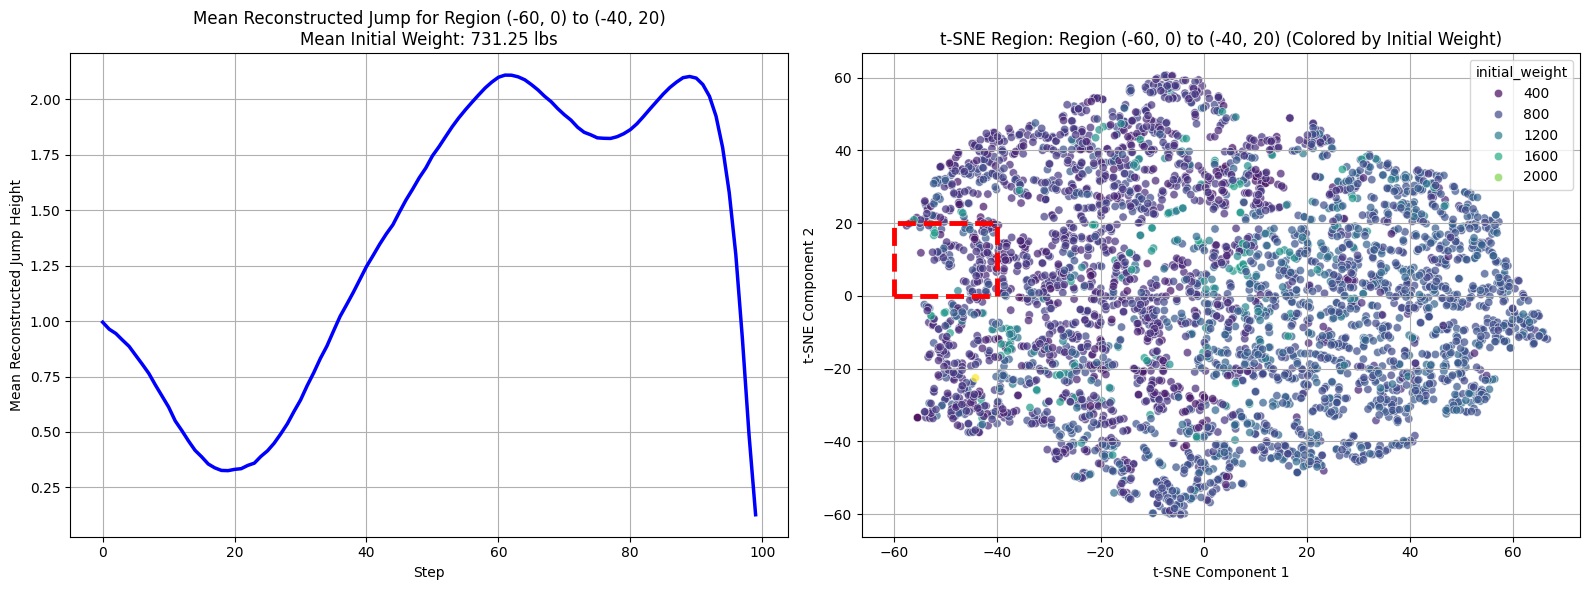

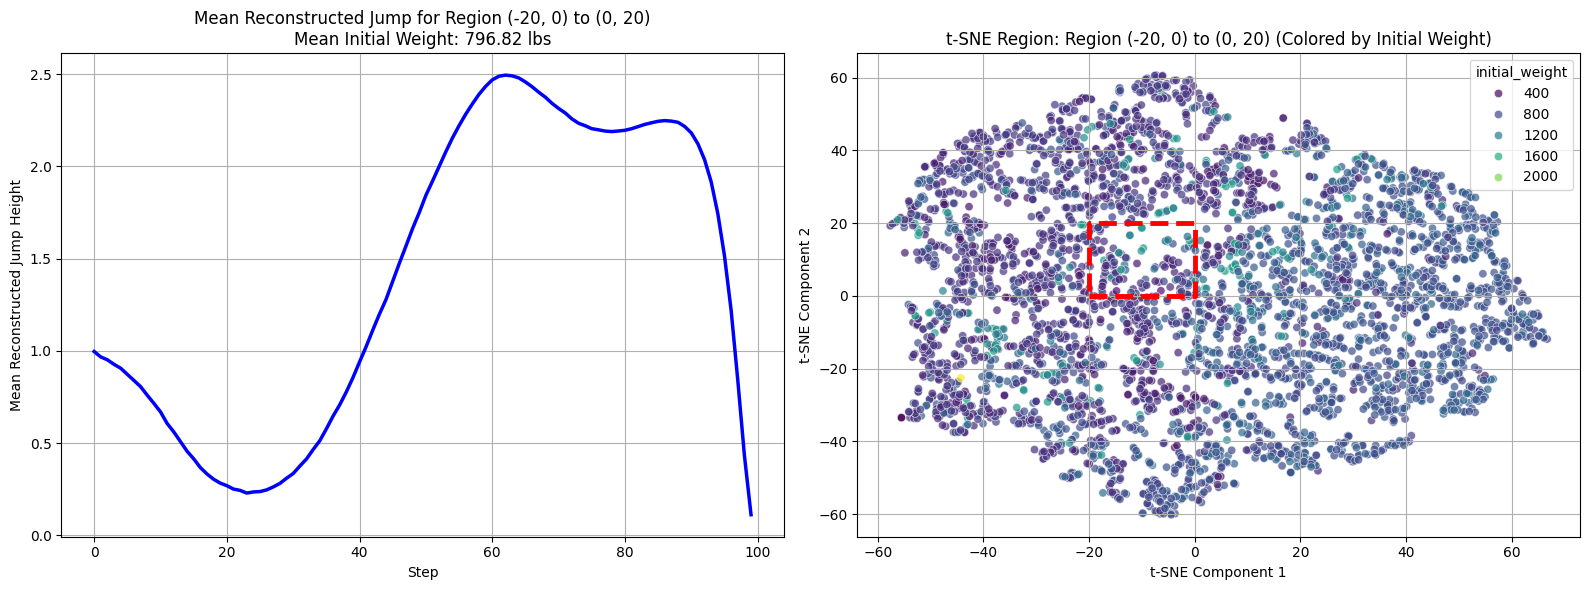

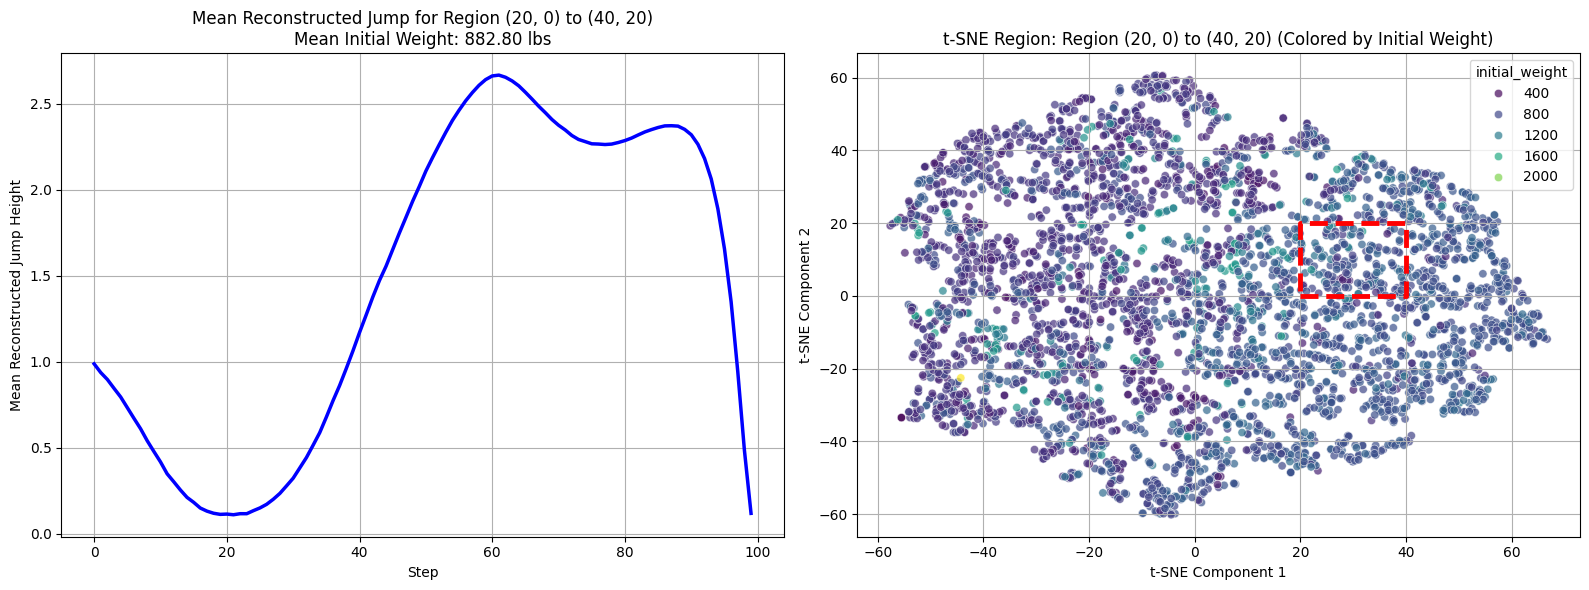

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

region_1 = sampled_df[
    (sampled_df["tsne_combined_1"] >= -20) & (sampled_df["tsne_combined_1"] <= 0) &
    (sampled_df["tsne_combined_2"] >= 0) & (sampled_df["tsne_combined_2"] <= 20)
]

region_2 = sampled_df[
    (sampled_df["tsne_combined_1"] >= -60) & (sampled_df["tsne_combined_1"] <= -40) &
    (sampled_df["tsne_combined_2"] >= 0) & (sampled_df["tsne_combined_2"] <= 20)
]

region_3 = sampled_df[
    (sampled_df["tsne_combined_1"] >= 20) & (sampled_df["tsne_combined_1"] <= 40) &
    (sampled_df["tsne_combined_2"] >= 0) & (sampled_df["tsne_combined_2"] <= 20)
]


def get_mean_reconstructed_jump(region_df):
    """Computes the mean reconstructed jump for a given region."""
    reconstructed_jumps = np.array([get_reconstructed_jump(row["latent_space"]) for _, row in region_df.iterrows()])
    return np.mean(reconstructed_jumps, axis=0)  # Compute mean across all jumps


def plot_mean_region_jumps(region_df, x_range, y_range, save_path):
    """Plots the mean reconstructed jump and highlights the selected t-SNE region, displaying mean weight."""
    x_min, x_max = x_range
    y_min, y_max = y_range
    region_name = f"Region ({x_min}, {y_min}) to ({x_max}, {y_max})"

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))  

    # Compute and plot the mean reconstructed jump
    mean_jump = get_mean_reconstructed_jump(region_df)
    axes[0].plot(mean_jump, linewidth=2.5, color="blue")
    
    # Compute the mean initial weight
    mean_weight = region_df["initial_weight"].mean()
    
    axes[0].set_title(f"Mean Reconstructed Jump for {region_name}\nMean Initial Weight: {mean_weight:.2f} lbs")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Mean Reconstructed Jump Height")
    axes[0].grid(True)

    # Scatter plot in t-SNE space colored by INITIAL_WEIGHT
    sns.scatterplot(x="tsne_combined_1", y="tsne_combined_2", 
                    data=sampled_df, alpha=0.7, hue="initial_weight", palette="viridis", ax=axes[1])

    # Highlight the selected region
    axes[1].plot([x_min, x_max, x_max, x_min, x_min], 
                 [y_min, y_min, y_max, y_max, y_min], 
                 color="red", linestyle="dashed", linewidth=3.5)  

    axes[1].set_xlabel("t-SNE Component 1")
    axes[1].set_ylabel("t-SNE Component 2")
    axes[1].set_title(f"t-SNE Region: {region_name} (Colored by Initial Weight)")
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")  # Save the plot
    plt.show()


# Save each plot as an image with correct regions
plot_mean_region_jumps(region_2, (-60, -40), (0, 20), "region_2_mean_plot.png")  # Matches region_2 definition
plot_mean_region_jumps(region_1, (-20, 0), (0, 20), "region_1_mean_plot.png")  # Matches region_1 definition
plot_mean_region_jumps(region_3, (20, 40), (0, 20), "region_3_mean_plot.png")  # Matches region_3 definition



Average Jump Height for Region 1: 10.72 inches


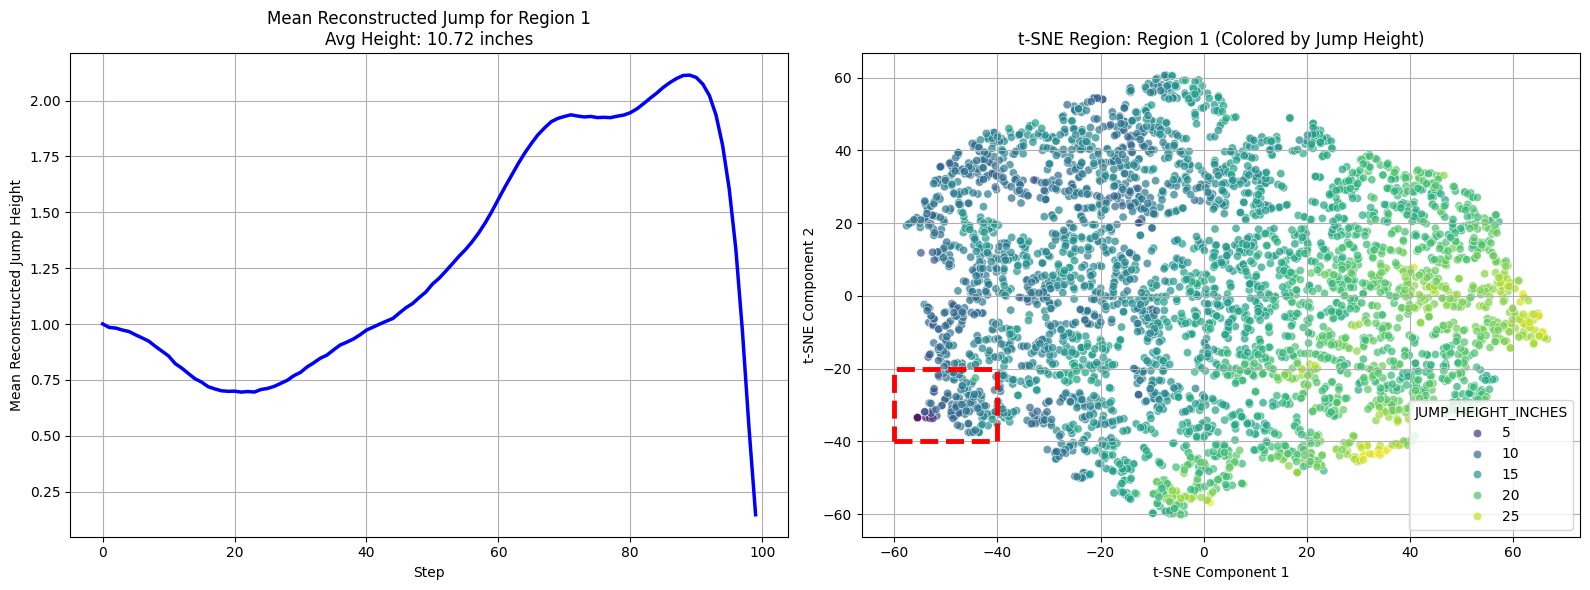

Average Jump Height for Region 2: 16.48 inches


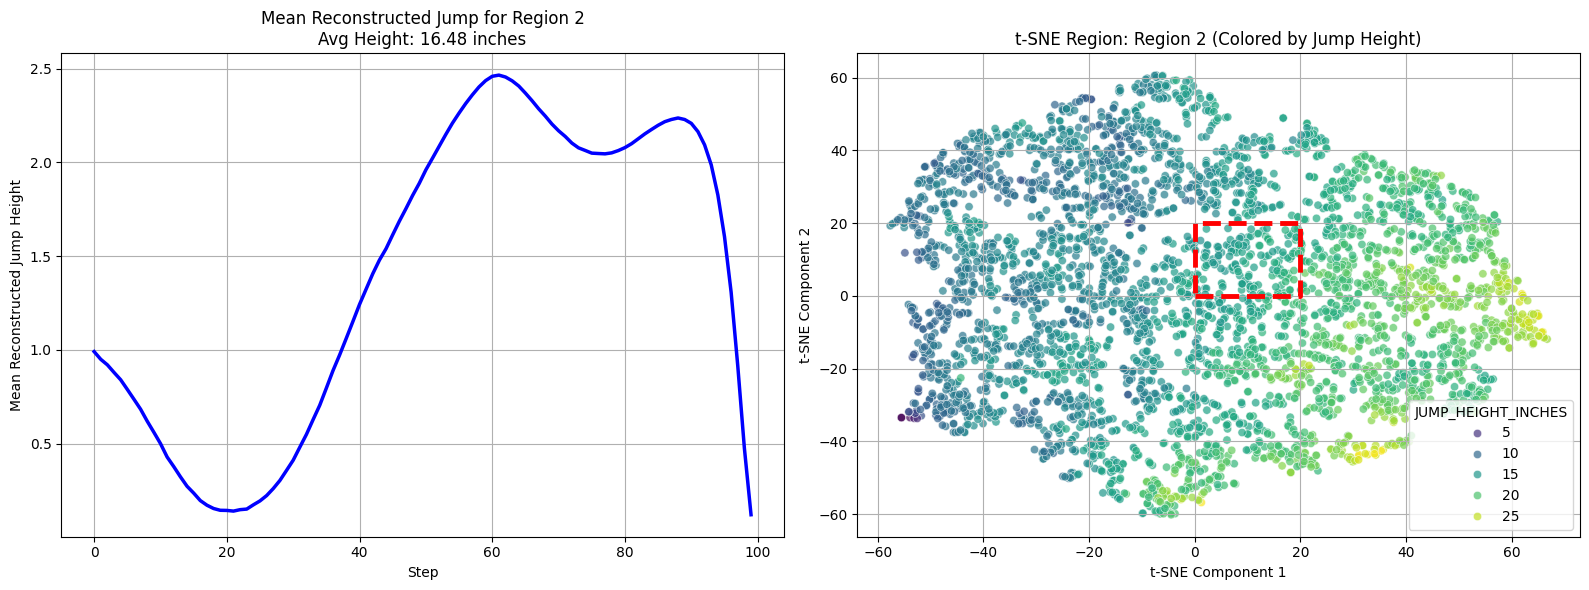

Average Jump Height for Region 3: 24.47 inches


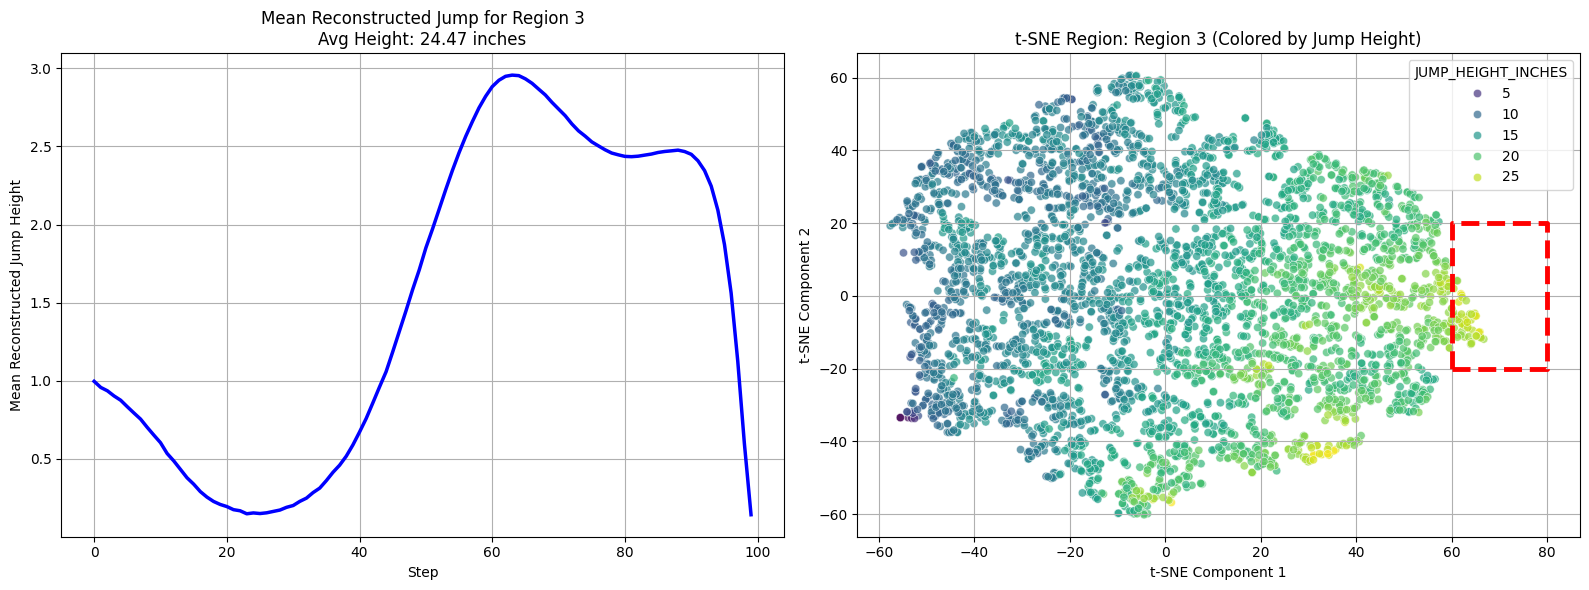

In [187]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define new regions based on the updated x and y ranges
region_1 = sampled_df[
    (sampled_df["tsne_combined_1"] >= -60) & (sampled_df["tsne_combined_1"] <= -40) &
    (sampled_df["tsne_combined_2"] >= -40) & (sampled_df["tsne_combined_2"] <= -20)
]  # Region 1

region_2 = sampled_df[
    (sampled_df["tsne_combined_1"] >= 0) & (sampled_df["tsne_combined_1"] <= 20) &
    (sampled_df["tsne_combined_2"] >= 0) & (sampled_df["tsne_combined_2"] <= 20)
]  # Region 2

region_3 = sampled_df[
    (sampled_df["tsne_combined_1"] >= 60) & (sampled_df["tsne_combined_1"] <= 80) &
    (sampled_df["tsne_combined_2"] >= -20) & (sampled_df["tsne_combined_2"] <= 20)
]  # Region 3


def get_mean_reconstructed_jump(region_df):
    """Computes the mean reconstructed jump for a given region."""
    reconstructed_jumps = np.array([get_reconstructed_jump(row["latent_space"]) for _, row in region_df.iterrows()])
    return np.mean(reconstructed_jumps, axis=0)  # Compute mean across all jumps


def plot_region_with_mean_jump(region_df, x_range, y_range, region_name, save_path):
    """Plots the mean reconstructed jump and highlights the selected t-SNE region."""
    x_min, x_max = x_range
    y_min, y_max = y_range

    # Compute the mean jump height
    mean_jump_height = region_df["JUMP_HEIGHT_INCHES"].mean()
    print(f"Average Jump Height for {region_name}: {mean_jump_height:.2f} inches")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))  

    # Compute and plot the mean reconstructed jump
    mean_jump = get_mean_reconstructed_jump(region_df)
    axes[0].plot(mean_jump, linewidth=2.5, color="blue")
    axes[0].set_title(f"Mean Reconstructed Jump for {region_name}\nAvg Height: {mean_jump_height:.2f} inches")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Mean Reconstructed Jump Height")
    axes[0].grid(True)

    # Scatter plot for t-SNE space
    sns.scatterplot(x="tsne_combined_1", y="tsne_combined_2", 
                    data=sampled_df, alpha=0.7, hue="JUMP_HEIGHT_INCHES", palette="viridis", ax=axes[1])

    # Highlight the selected region
    axes[1].plot([x_min, x_max, x_max, x_min, x_min], 
                 [y_min, y_min, y_max, y_max, y_min], 
                 color="red", linestyle="dashed", linewidth=3.5)  

    axes[1].set_xlabel("t-SNE Component 1")
    axes[1].set_ylabel("t-SNE Component 2")
    axes[1].set_title(f"t-SNE Region: {region_name} (Colored by Jump Height)")
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")  # Save the plot
    plt.show()


# Define regions and their coordinates
regions = [
    (region_1, (-60, -40), (-40, -20), "Region 1"),
    (region_2, (0, 20), (0, 20), "Region 2"),
    (region_3, (60, 80), (-20, 20), "Region 3")
]

# Plot and save each region's mean jump with t-SNE highlight
for region_df, x_range, y_range, region_name in regions:
    # save_path = f"{region_name.replace(' ', '_').lower()}_mean_jump.png"
    plot_region_with_mean_jump(region_df, x_range, y_range, region_name, save_path)


In [175]:
data.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space,latent_space_consistency,reconstruction_loss,reconstruction,total_sessions,start_year,years_training,outlier,first_session_date,relative_session
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,NaN,10.206,10.628,10.37,10.46,18.494496,10.206,8.676187,8.861041,0.424,22.037504,22.51405,22.507032,40.056,result\nPOSITIVE_IMPULSE 305.515939\nPOSITI...,2013.020207,124.807,result\nLANDING_RFD 44361.941\nLANDING_RFD ...,1.851,242.302,-0.095,40.056,result\nPEAK_LANDING_FORCE 2750.440318\nPEA...,3826.224,0.389,49.86295,result\nLANDING_IMPULSE 74.115300\nLANDING_...,35920.0,result\nMEAN_ECCENTRIC_FORCE 541.478054\nME...,216.720458,3.928942,57.900625,result\nECCENTRIC_BRAKING_IMPULSE 24.932420...,637.786472,794.063848,result\nECCENTRIC_BRAKING_RFD 3193.798450\n...,result\nECCENTRIC_DECEL_RFD 3196.428571\nEC...,57.948306,result\nPEAK_ECCENTRIC_FORCE 1077.440318\nP...,19.533001,4850.841392,result\nECCENTRIC_DEC

In [176]:
np.min(data["downsampled_time_series"][0])

0.09587358683347702

In [177]:
save_path_1 = "region_1_reconstructed_jumps.png"
save_path_2 = "region_2_reconstructed_jumps.png"
save_path_3 = "region_3_reconstructed_jumps.png"


### Latent Space Dimensions and Their Relation to Jump Height Using PCA

To account for multicollinearity: 

Utilize PCA, where each principal component is a linear combination of the original features. 

New axes that maximize variance in data -> each PC combination of original features

PCs uncorrelated, removing multicollinearity -> because some of the features are linear combinations of others, PCA compresses correlated features into fewer components (16 highly correalted -> 5 uncorrelated PCs)


Allows to fit more stable OLS without issues and instability from multicollinearity. 


### Create Columns for Each Latent Dim

In [178]:
import pandas as pd
import numpy as np

# Convert latent space column into a NumPy array
latent_matrix = np.stack(data['latent_space'].values)  

# Create new columns for each latent dim
latent_df = pd.DataFrame(latent_matrix, columns=[f'latent_{i}' for i in range(latent_matrix.shape[1])])
data_expanded = pd.concat([data, latent_df], axis=1)
data_expanded = data_expanded.drop(columns=['latent_space'])


### Reduce Dimensionality with PCA

In [179]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Convert latent space column into a NumPy array
latent_matrix = np.stack(data['latent_space'].values)  
latent_df = pd.DataFrame(latent_matrix, columns=[f'latent_{i}' for i in range(latent_matrix.shape[1])])

data_expanded = pd.concat([data, latent_df], axis=1)
data_expanded = data_expanded.drop(columns=['latent_space'])
X = data_expanded[[f'latent_{i}' for i in range(latent_matrix.shape[1])]]  


imputer = SimpleImputer(strategy='mean')  
X_imputed = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

n_components = 5  
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", sum(pca.explained_variance_ratio_))


Explained Variance Ratio: [0.34989996 0.31147712 0.12227477 0.07687573 0.05912856]
Total Variance Explained: 0.9196561426231392


In [180]:
data_expanded.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space_consistency,reconstruction_loss,reconstruction,total_sessions,start_year,years_training,outlier,first_session_date,relative_session,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,NaN,10.206,10.628,10.37,10.46,18.494496,10.206,8.676187,8.861041,0.424,22.037504,22.51405,22.507032,40.056,result\nPOSITIVE_IMPULSE 305.515939\nPOSITI...,2013.020207,124.807,result\nLANDING_RFD 44361.941\nLANDING_RFD ...,1.851,242.302,-0.095,40.056,result\nPEAK_LANDING_FORCE 2750.440318\nPEA...,3826.224,0.389,49.86295,result\nLANDING_IMPULSE 74.115300\nLANDING_...,35920.0,result\nMEAN_ECCENTRIC_FORCE 541.478054\nME...,216.720458,3.928942,57.900625,result\nECCENTRIC_BRAKING_IMPULSE 24.932420...,637.786472,794.063848,result\nECCENTRIC_BRAKING_RFD 3193.798450\n...,result\nEC

### Show Results of OLS Regression on PCA Data

In [181]:
data["initial_weight"] = data["total_force"].apply(lambda x: x[0] if isinstance(x, list) or isinstance(x, np.ndarray) else np.nan)

In [182]:
# randomly pick jump 
# get latent space reconstruction
# take latent space add vector associated with PC5
# make reconstruction of that new vector

# multiplying by small increments / scaling by different values shows how it changes in certain directions shape 

# get vector associated with PC5

### Interpretation

- Highest Positive Impact: PC2: +0.5931 -> strongest positive influence on jump height
- Most Negative Impact: PC5: -3.6056 -> strongest negative influence on jump height

### PCA Loadings Calculation Heatmap Visualization

- How much each Principal Component Is Influenced by Original Latent Features
- Correlation between latent space dimension and principal component


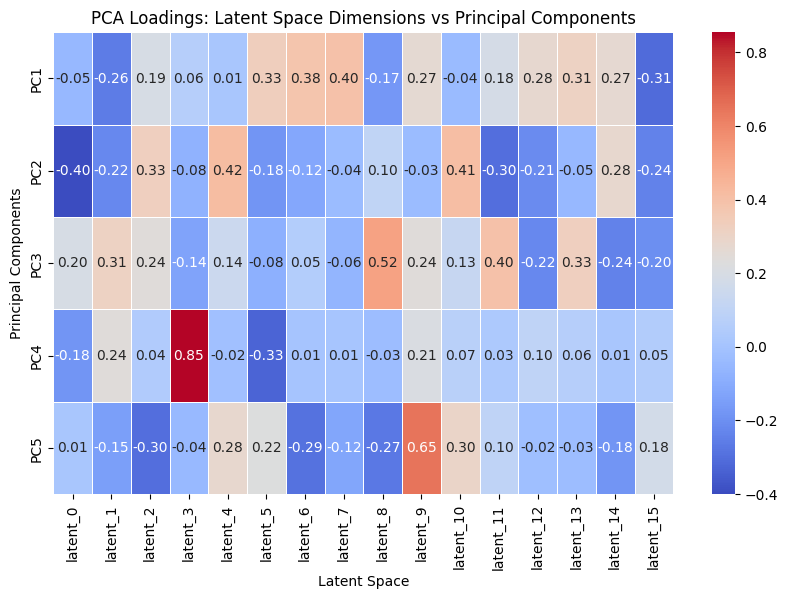

In [183]:
loadings = pd.DataFrame(pca.components_, columns=[f'latent_{i}' for i in range(latent_matrix.shape[1])], index=[f'PC{i+1}' for i in range(n_components)])

# print("PCA Loadings (correlation between latent spaces and PCs):")
# print(loadings)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("PCA Loadings: Latent Space Dimensions vs Principal Components")
plt.xlabel("Latent Space")
plt.ylabel("Principal Components")
plt.show()


### Visualizing How Changes in Principal Components of a Latent Vector Affect Jump Reconstruction

### Modifying Latent Vector:
For each latent vector, isolate one principal component (PC) at a time by modifying the vector (add scaling factor time principal component vector to original mean tensor). All components except for the selected PC are set to zero.

### Inverse PCA Transform:
The modified latent vector, which now only contains the selected principal component, is transformed back to the original latent space using an inverse PCA transform. This is done to reconstruct the jump using only the selected PC.

### Reconstruction with Autoencoder:
The modified latent vector (after applying inverse PCA) is passed through the autoencoder's decoder to generate the reconstructed jump.

### Visualizing the Effect:
The effect of modifying each principal component is visualized by plotting the reconstructed jumps. Each plot compares the original jump (using the full latent vector) to the jump reconstructed with just the selected principal component, illustrating how each PC impacts the jump’s shape.

In [184]:
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])
data_pca = pd.concat([X_pca_df, data_expanded['JUMP_HEIGHT_INCHES']], axis=1)

X_new = sm.add_constant(X_pca_df)
model_pca = sm.OLS(data_pca['JUMP_HEIGHT_INCHES'], X_new).fit()

print(model_pca.summary())


                            OLS Regression Results                            
Dep. Variable:     JUMP_HEIGHT_INCHES   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     4961.
Date:                Fri, 14 Mar 2025   Prob (F-statistic):               0.00
Time:                        21:57:07   Log-Likelihood:                -75181.
No. Observations:               30012   AIC:                         1.504e+05
Df Residuals:                   30006   BIC:                         1.504e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.1896      0.017    946.587      0.0

In [207]:
X_pca_df

,PC1,PC2,PC3,PC4,PC5
0,1.265735,3.286070,2.400325,2.815255,-0.417221
1,0.548134,1.260782,1.523605,6.960191,12.041902
2,2.266209,1.241660,1.794157,2.397226,-0.328558
3,4.148713,1.780997,0.627949,0.299930,-0.324497
4,5.299203,2.412457,1.224111,0.027824,0.079467
...,...,...,...,...,...
30007,-3.011612,0.663149,-1.306758,0.864237,0.244438
30008,-1.476769,0.836828,-1.681095,0.956681,0.611932
30009,-0.253044,1.210481,-2.065333,1.081163,0.376423
30010,-2.001898,1.380603,-1.657090,0.522963,0.927305


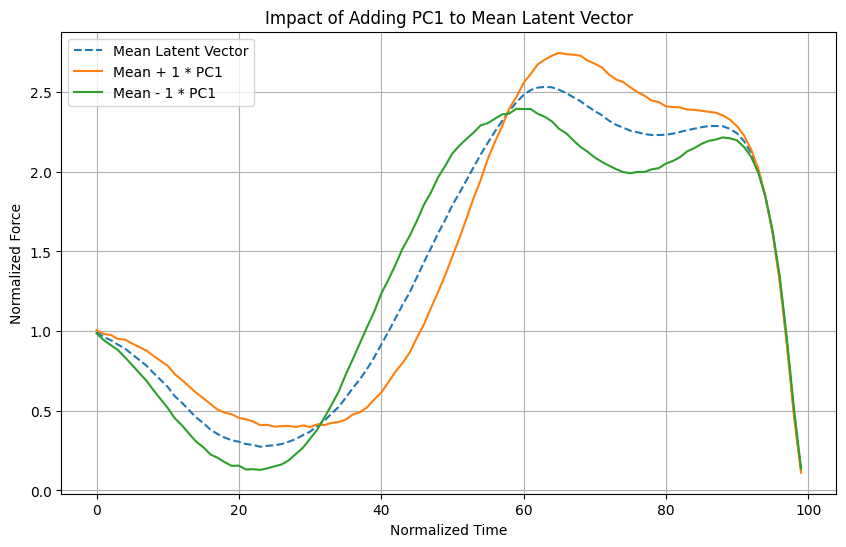

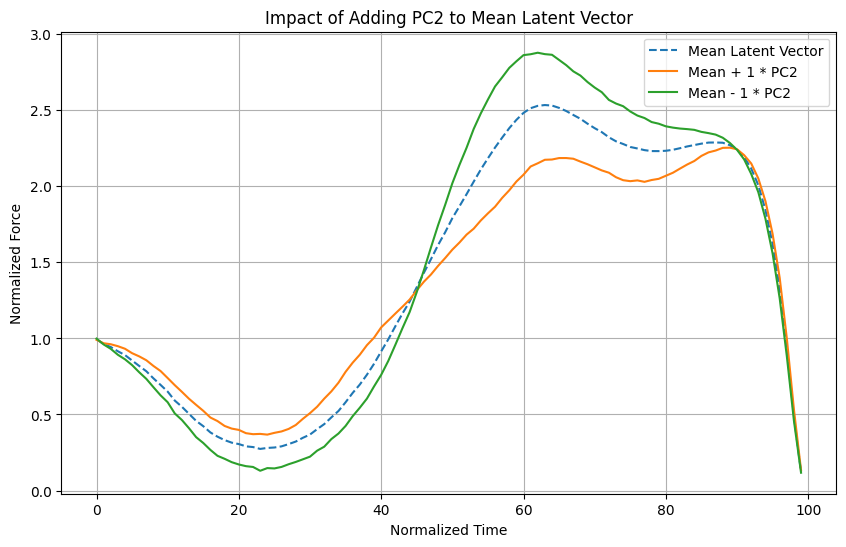

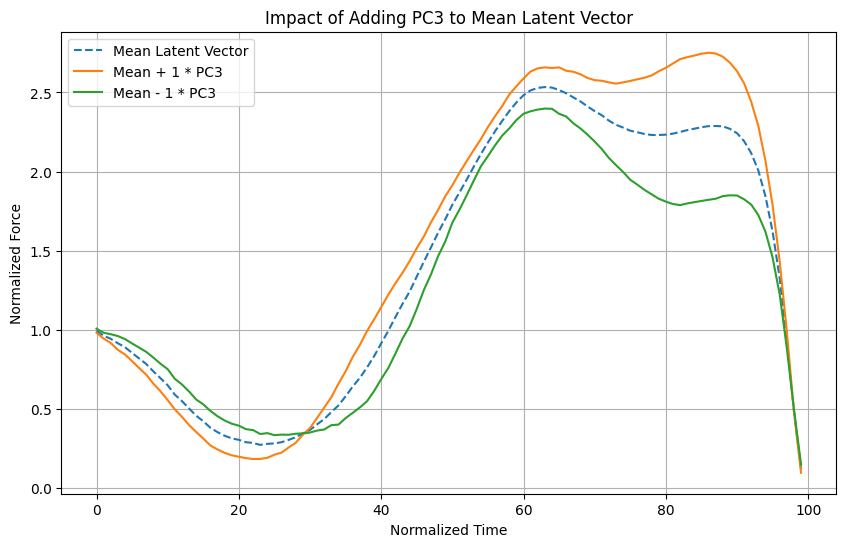

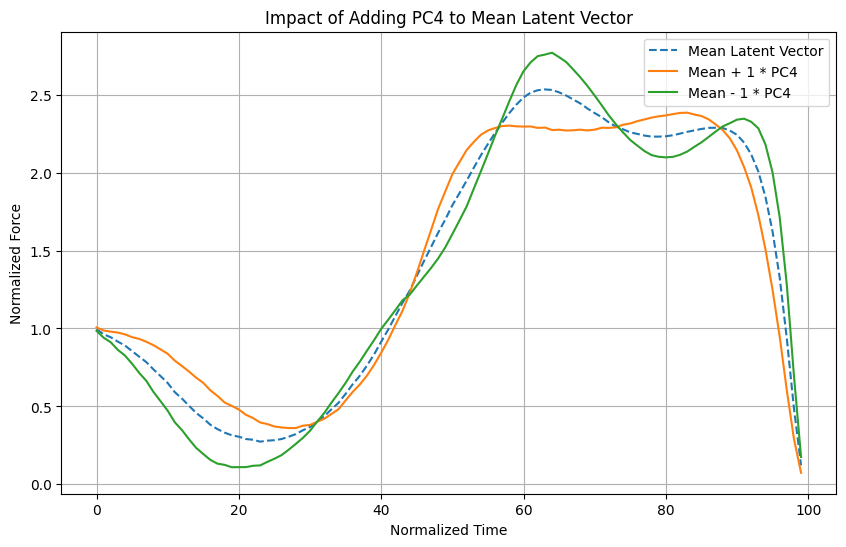

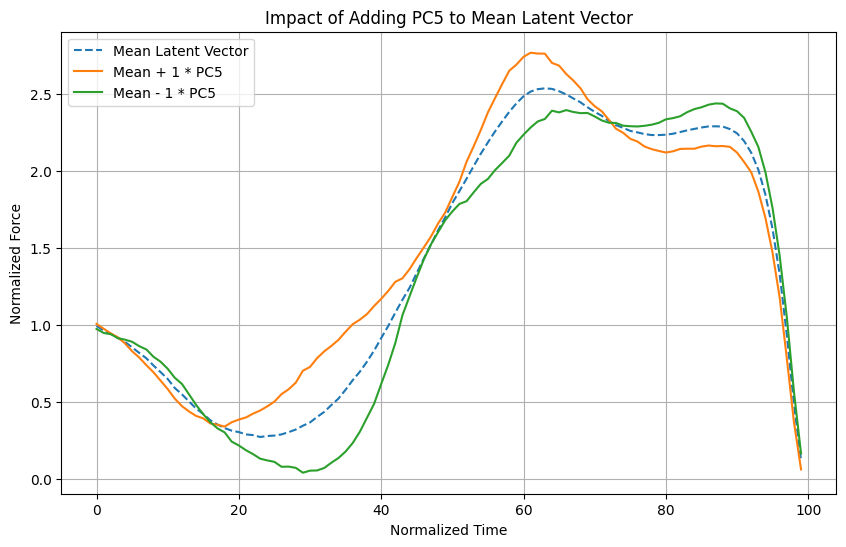

In [185]:
import torch
import numpy as np
import matplotlib.pyplot as plt

mean_tensor = torch.tensor([(np.mean(data["latent_space"], axis=0))]).float()

pc_directions = {
    f"PC{i+1}": torch.tensor(pca.components_[i]) for i in range(5)  
}

scaling_factor = 1  

for pc_label, pc_vector in pc_directions.items():
    modified_tensor = (mean_tensor + scaling_factor * pc_vector).float()
    modified_tensor_2 = (mean_tensor - scaling_factor * pc_vector).float()

    original_reconstruction = autoencoder.decoder(mean_tensor).detach().numpy()[0]
    modified_reconstruction = autoencoder.decoder(modified_tensor).detach().numpy()[0]
    modified_reconstruction_2 = autoencoder.decoder(modified_tensor_2).detach().numpy()[0]

    plt.figure(figsize=(10, 6))
    plt.plot(original_reconstruction, label="Mean Latent Vector", linestyle="--")
    plt.plot(modified_reconstruction, label=f"Mean + {scaling_factor} * {pc_label}", linestyle="-")
    plt.plot(modified_reconstruction_2, label=f"Mean - {scaling_factor} * {pc_label}", linestyle="-")
    plt.xlabel("Normalized Time")
    plt.ylabel("Normalized Force")
    plt.title(f"Impact of Adding {pc_label} to Mean Latent Vector")
    plt.legend()
    plt.grid(True)
    plt.show()

In [186]:
# normalize based on intial combined_force value ^